## 1. Setup — Imports & Configuration

In [26]:
# ─── CORE LIBRARIES ──────────────────────────────────────────────────────────
import pandas as pd               # DataFrames — our main data structure
import numpy as np                # Numerical operations
import matplotlib.pyplot as plt   # Base plotting engine
import seaborn as sns             # Higher-level statistical charts
import pickle                     # Save/load trained models to disk
import os                         # File and folder operations

# ─── SCIKIT-LEARN: PREPROCESSING ──────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
# LabelEncoder  — converts text categories to integers (e.g. 'yes'→1, 'no'→0)
# StandardScaler — scales all features to mean=0, std=1 so no feature dominates

# ─── SCIKIT-LEARN: MODEL SELECTION ────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split,   # Split data into train and test sets
    cross_val_score,    # Evaluate model across multiple splits
    StratifiedKFold,    # K-fold that preserves class balance per fold
    GridSearchCV        # Systematically search for best hyperparameters
)

# ─── SCIKIT-LEARN: MODELS ─────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression    # Linear classifier
from sklearn.ensemble import RandomForestClassifier    # Ensemble of decision trees
from sklearn.svm import SVC                           # Support Vector Classifier
from sklearn.neighbors import KNeighborsClassifier    # K-Nearest Neighbours
from sklearn.tree import DecisionTreeClassifier       # Single decision tree

# ─── SCIKIT-LEARN: EVALUATION METRICS ─────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,       # % of all predictions that are correct
    precision_score,      # Of predicted Pass, how many actually passed?
    recall_score,         # Of actual Pass, how many did we catch?
    f1_score,             # Harmonic mean of precision and recall
    classification_report,
    confusion_matrix,
    roc_curve,            # ROC curve data points
    auc                   # Area Under the ROC Curve
)

# ─── XGBOOST ──────────────────────────────────────────────────────────────────
# Install if needed: !pip install xgboost
from xgboost import XGBClassifier   # Gradient boosting — often top performer

import warnings
warnings.filterwarnings('ignore')   # Suppress non-critical warnings

pd.set_option('display.max_columns', None)   # Show all columns in DataFrames

print('All libraries loaded successfully ✅')


All libraries loaded successfully ✅


## 2. Load & Explore Data

We start with the Math dataset for exploration. The Portuguese dataset is used in the extended pipeline (Section 7).

In [27]:
# Load the Math dataset
# sep=';' is critical — this CSV uses semicolons, not commas
df = pd.read_csv('../data/student-mat.csv', sep=';')

print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print('\nFirst 5 rows:')
df.head()


Shape: 395 rows × 33 columns

First 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [28]:
# Column types and non-null counts
# Look for: unexpected 'object' types where you expect numbers,
# and any columns with null values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [29]:
# Count missing values per column
# This dataset has none, but in real projects this step often
# triggers decisions about dropping or imputing values
print('Missing values per column:')
print(df.isnull().sum())


Missing values per column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [30]:
# Statistical summary: min, max, mean, std, quartiles
# Good for spotting suspicious values (e.g. negative ages, unrealistic ranges)
df.describe()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## 3. Target Variable Creation

We convert `G3` (a 0–20 score) into a binary label: **1 = Pass** (score ≥ 10) or **0 = Fail** (score < 10).

This is a **design decision** — 10/20 is the natural pass mark (equivalent to 50%). A different researcher might use 12, or create grade bands. Your threshold directly affects what the model learns.

In [31]:
# Create the pass/fail target column
# lambda applies a small inline function to every value in G3:
#   if grade >= 10 → return 1 (Pass)
#   if grade <  10 → return 0 (Fail)
df['pass'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)

print('Grade distribution (0=Fail, 1=Pass):')
print(df['pass'].value_counts())

# .mean() works here because Pass=1 and Fail=0 — the average IS the pass rate
print(f'\nPass rate: {df["pass"].mean()*100:.1f}%')
print(f'Fail rate: {(df["pass"] == 0).mean()*100:.1f}%')


Grade distribution (0=Fail, 1=Pass):
pass
1    265
0    130
Name: count, dtype: int64

Pass rate: 67.1%
Fail rate: 32.9%


## 4. Exploratory Data Analysis (EDA)

EDA answers specific questions using visuals before any modelling begins.
The goal is to understand the data and find which features are worth investigating.

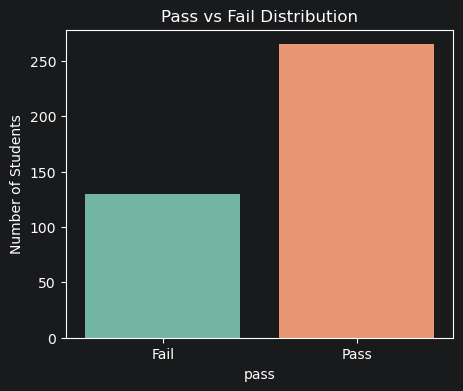

In [32]:
# ── PLOT 1: Pass/Fail count ──────────────────────────────────────────────────
# Question: Is the dataset balanced?
# If 95% of students pass, a model that always predicts 'pass'
# would look 95% accurate without learning anything useful.
plt.figure(figsize=(5, 4))
sns.countplot(x='pass', data=df, palette='Set2')
plt.title('Pass vs Fail Distribution')
plt.xticks([0, 1], ['Fail', 'Pass'])
plt.ylabel('Number of Students')
plt.show()


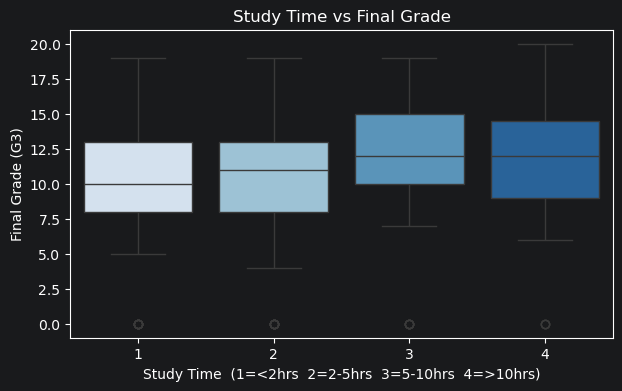

In [33]:
# ── PLOT 2: Study time vs Final grade ────────────────────────────────────────
# Question: Does studying more actually correlate with better grades?
# A boxplot shows the median and spread per group.
# If boxes shift upward as study time increases, there's a real relationship.
plt.figure(figsize=(7, 4))
sns.boxplot(x='studytime', y='G3', data=df, palette='Blues')
plt.title('Study Time vs Final Grade')
plt.xlabel('Study Time  (1=<2hrs  2=2-5hrs  3=5-10hrs  4=>10hrs)')
plt.ylabel('Final Grade (G3)')
plt.show()


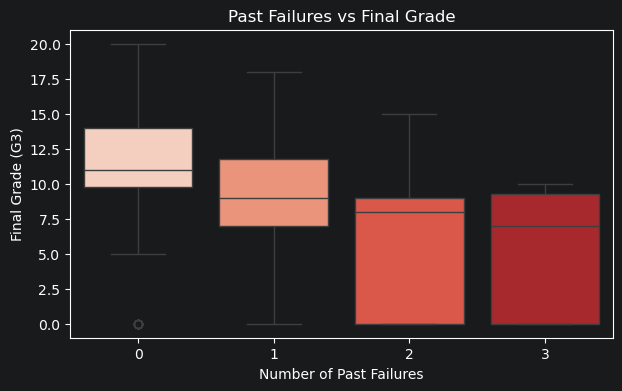

In [34]:
# ── PLOT 3: Past failures vs Final grade ─────────────────────────────────────
# Question: Do past failures predict future failure?
# This is one of the strongest features in the dataset.
# Expect boxes to shift downward as failures increase.
plt.figure(figsize=(7, 4))
sns.boxplot(x='failures', y='G3', data=df, palette='Reds')
plt.title('Past Failures vs Final Grade')
plt.xlabel('Number of Past Failures')
plt.ylabel('Final Grade (G3)')
plt.show()


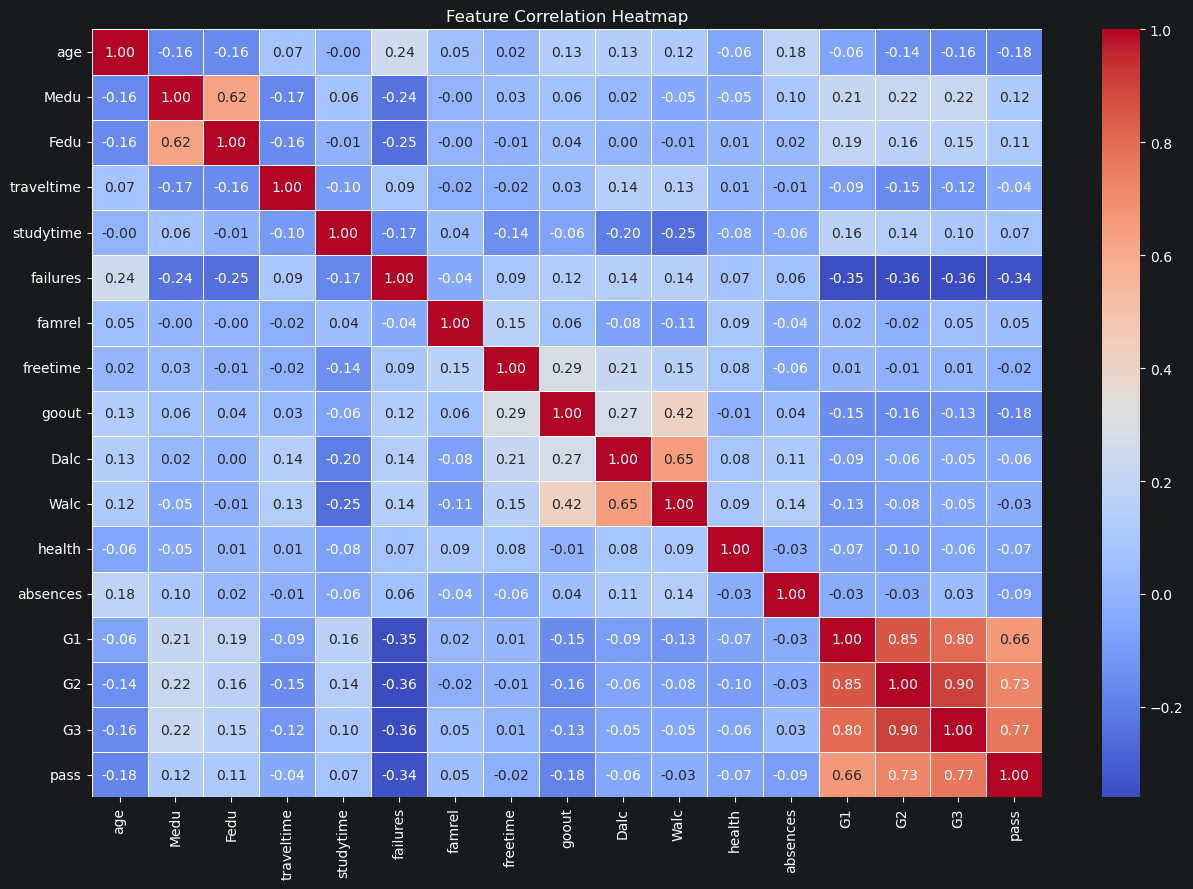

In [35]:
# ── PLOT 4: Correlation heatmap ───────────────────────────────────────────────
# .corr() computes Pearson correlation between every pair of numeric columns.
# Values range from -1 (perfect negative) to +1 (perfect positive).
#
# How to read it:
#   - Find the G3 row/column — strongest colours = best predictors
#   - Features strongly correlated WITH EACH OTHER may be redundant
#   - G1 and G2 will be very strongly correlated with G3 (that's expected)
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(13, 9))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


## 5. Preprocessing

Three steps:
1. Drop columns we can't or shouldn't use
2. Encode text columns as numbers
3. Scale all features to the same range

In [36]:
# ── Step 1: Drop grade columns ───────────────────────────────────────────────
# G3 — we already extracted our target from it
# G1, G2 — prior period grades. Keeping them would let the model cheat:
#           it would lean on grades instead of learning from lifestyle factors.
#           Dropping them makes the prediction useful at the START of term.
features_to_drop = ['G3', 'G1', 'G2']
df_model = df.drop(columns=features_to_drop)

# ── Step 2: Encode categorical (text) columns ─────────────────────────────────
# ML models are mathematical — they can't process strings.
# LabelEncoder converts each unique value to an integer, alphabetically:
#   sex:     F→0, M→1
#   address: R→0, U→1
#   higher:  no→0, yes→1
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
print('Categorical columns being encoded:', categorical_cols)

le = LabelEncoder()
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])

print('\nAll columns now numeric ✅')
df_model.head()


Categorical columns being encoded: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

All columns now numeric ✅


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,pass
0,0,0,18,1,0,0,4,4,0,4,0,1,2,2,0,1,0,0,0,1,1,0,0,4,3,4,1,1,3,6,0
1,0,0,17,1,0,1,1,1,0,2,0,0,1,2,0,0,1,0,0,0,1,1,0,5,3,3,1,1,3,4,0
2,0,0,15,1,1,1,1,1,0,2,2,1,1,2,3,1,0,1,0,1,1,1,0,4,3,2,2,3,3,10,1
3,0,0,15,1,0,1,4,2,1,3,1,1,1,3,0,0,1,1,1,1,1,1,1,3,2,2,1,1,5,2,1
4,0,0,16,1,0,1,3,3,2,2,1,0,1,2,0,0,1,1,0,1,1,0,0,4,3,2,1,2,5,4,1


In [37]:
# ── Step 3: Separate features and target ──────────────────────────────────────
# X = everything the model learns FROM (all columns except 'pass')
# y = what the model is trying to predict ('pass')
X = df_model.drop(columns=['pass'])
y = df_model['pass']

print('Features shape:', X.shape)   # (395, 30) — 395 students, 30 features
print('Target shape:  ', y.shape)   # (395,)


Features shape: (395, 30)
Target shape:   (395,)


In [38]:
# ── Step 4: Scale features ────────────────────────────────────────────────────
# Different features have very different ranges:
#   age: 15–22  |  absences: 0–93  |  studytime: 1–4
# Without scaling, features with larger ranges dominate the model.
# StandardScaler transforms each feature to mean=0, std=1.
#
# NOTE: We re-do this inside the extended pipeline (Section 7)
# using a function, so the scaler can be saved per dataset.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Scaling complete ✅')
print(f'Example — absences before: min={X["absences"].min()}, max={X["absences"].max()}')
print(f'Example — absences after:  min={X_scaled[:, X.columns.get_loc("absences")].min():.2f}, '
      f'max={X_scaled[:, X.columns.get_loc("absences")].max():.2f}')


Scaling complete ✅
Example — absences before: min=0, max=75
Example — absences after:  min=-0.71, max=8.67


## 6. Train-Test Split

We hide 20% of data from the model during training, then test on it at the end.
This simulates the model encountering data it has never seen — which is what happens in real use.

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,    # 20% held out for testing
    random_state=42,  # seed the shuffle so results are reproducible
    stratify=y        # ensure the 80/20 split preserves the pass/fail ratio
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')
print(f'\nPass rate in training set: {y_train.mean()*100:.1f}%')
print(f'Pass rate in test set:     {y_test.mean()*100:.1f}%')
# These should be nearly identical because of stratify=y


Training samples: 316
Testing samples:  79

Pass rate in training set: 67.1%
Pass rate in test set:     67.1%


## 7. Baseline Models (Logistic Regression & Random Forest)

We start with two models on the Math dataset as a baseline before the full pipeline in Section 9.

In [40]:
# ── Logistic Regression ───────────────────────────────────────────────────────
# Finds a linear boundary separating Pass from Fail.
# Each feature gets a weight — positive weights push toward Pass,
# negative weights push toward Fail.
# Fast, interpretable, and a strong baseline.
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# ── Random Forest ─────────────────────────────────────────────────────────────
# Builds 100 decision trees, each on a random subset of data and features.
# Final prediction = majority vote across all 100 trees.
# Handles non-linear relationships that Logistic Regression can't.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print('Baseline models trained ✅')


Baseline models trained ✅


## 8. Cross-Validation

A single train-test split could be lucky or unlucky. Cross-validation does **5 different splits**, trains and tests on each, and gives 5 scores. The mean is a much more reliable estimate of real performance.

In [41]:
# StratifiedKFold — like regular K-Fold but each fold keeps the pass/fail ratio
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# cross_val_score trains and tests the model 5 times, returns 5 F1 scores
lr_cv = cross_val_score(lr_model, X_scaled, y, cv=cv, scoring='f1')
rf_cv = cross_val_score(rf_model, X_scaled, y, cv=cv, scoring='f1')

print('Logistic Regression CV F1 scores:', lr_cv.round(3))
print(f'  Mean: {lr_cv.mean():.3f}  |  Std: {lr_cv.std():.3f}')
print(f'  (low std = stable model, consistent across different data splits)')

print('\nRandom Forest CV F1 scores:', rf_cv.round(3))
print(f'  Mean: {rf_cv.mean():.3f}  |  Std: {rf_cv.std():.3f}')


Logistic Regression CV F1 scores: [0.752 0.85  0.772 0.765 0.807]
  Mean: 0.789  |  Std: 0.035
  (low std = stable model, consistent across different data splits)

Random Forest CV F1 scores: [0.807 0.852 0.807 0.813 0.817]
  Mean: 0.819  |  Std: 0.017


## 9. Evaluate Baseline Models

**Accuracy** — overall correctness  
**Precision** — of predicted Pass, how many actually passed?  
**Recall** — of actual Pass, how many did we correctly identify?  
**F1 Score** — harmonic mean of Precision and Recall (our primary metric)

For this problem, **Recall matters most** — missing a student who will fail is more costly than a false alarm.

In [42]:
def evaluate_model(name, model, X_test, y_test):
    """Print all key metrics for a given model."""
    y_pred = model.predict(X_test)

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall   : {recall_score(y_test, y_pred):.4f}")
    print(f"  F1 Score : {f1_score(y_test, y_pred):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))

    return y_pred


lr_preds = evaluate_model('Logistic Regression', lr_model, X_test, y_test)
rf_preds = evaluate_model('Random Forest',       rf_model, X_test, y_test)



  Logistic Regression
  Accuracy : 0.6835
  Precision: 0.7258
  Recall   : 0.8491
  F1 Score : 0.7826

Classification Report:
              precision    recall  f1-score   support

        Fail       0.53      0.35      0.42        26
        Pass       0.73      0.85      0.78        53

    accuracy                           0.68        79
   macro avg       0.63      0.60      0.60        79
weighted avg       0.66      0.68      0.66        79


  Random Forest
  Accuracy : 0.6835
  Precision: 0.7188
  Recall   : 0.8679
  F1 Score : 0.7863

Classification Report:
              precision    recall  f1-score   support

        Fail       0.53      0.31      0.39        26
        Pass       0.72      0.87      0.79        53

    accuracy                           0.68        79
   macro avg       0.63      0.59      0.59        79
weighted avg       0.66      0.68      0.66        79



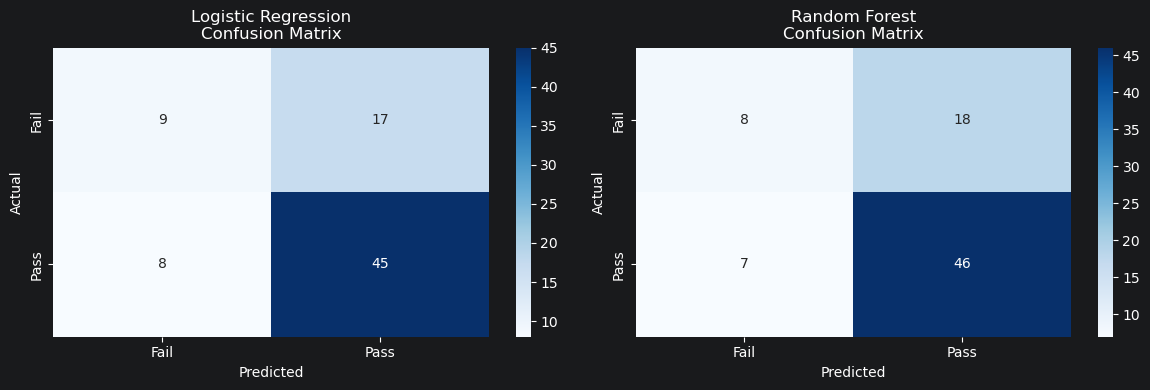

In [43]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
# A 2x2 table showing the breakdown of correct and incorrect predictions:
#   Top-left  (TN) — correctly predicted Fail
#   Top-right (FP) — predicted Pass but actually Failed  ← false alarm
#   Bot-left  (FN) — predicted Fail but actually Passed  ← costly miss
#   Bot-right (TP) — correctly predicted Pass
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(axes,
                             [lr_preds, rf_preds],
                             ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Fail', 'Pass'],
                yticklabels=['Fail', 'Pass'])
    ax.set_title(f'{title}\nConfusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()


## 10. Feature Importance (Random Forest)

Random Forest tracks how much each feature reduced prediction error across all 100 trees. This tells us which student attributes actually drive performance.

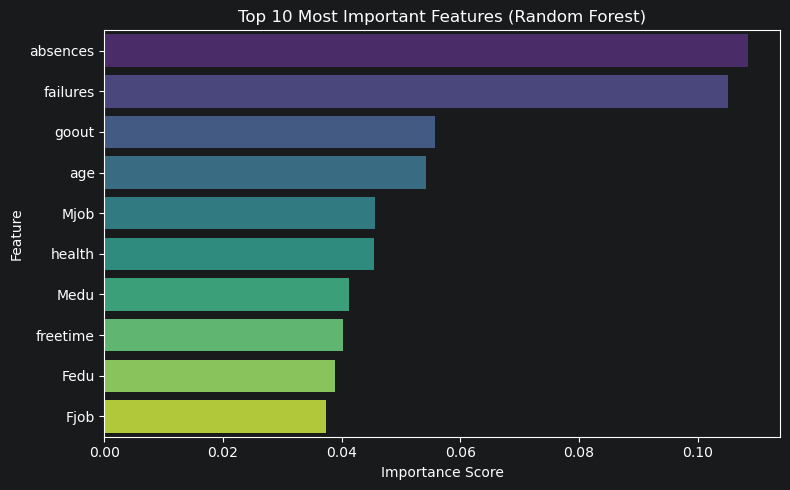


Top 5 most influential features:
  1. absences (0.1085)
  2. failures (0.1051)
  3. goout (0.0557)
  4. age (0.0542)
  5. Mjob (0.0457)


In [44]:
importances = rf_model.feature_importances_

# Build a sorted DataFrame for easy plotting
feat_df = pd.DataFrame({
    'Feature':    X.columns.tolist(),
    'Importance': importances
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 5 most influential features:')
for i, (_, row) in enumerate(feat_df.head(5).iterrows(), 1):
    print(f'  {i}. {row["Feature"]} ({row["Importance"]:.4f})')


## 11. Extended Pipeline — All Models, Both Datasets, Save to Disk

Now we build the production pipeline:
- A reusable `prepare_dataset()` function handles all preprocessing
- 6 models are trained on both the Math and Portuguese datasets
- All trained models and scalers are saved as `.pkl` files
- The Streamlit app (`app.py`) loads these saved files to serve predictions

Run this section after the baseline exploration above.

In [45]:
# Create the models/ folder if it doesn't exist yet
os.makedirs('../models', exist_ok=True)
print('models/ folder ready ✅')


models/ folder ready ✅


In [46]:
def prepare_dataset(csv_path):
    """
    Load and preprocess a student CSV file end-to-end.

    This function is the single source of truth for preprocessing.
    Using a function ensures the Math and Portuguese datasets go through
    EXACTLY the same steps — no copy-paste errors.

    Returns:
        X_scaled        — scaled feature matrix (what models train on)
        y               — target labels (0=Fail, 1=Pass)
        X               — unscaled DataFrame (needed for feature names)
        scaler          — fitted scaler (MUST be saved — app uses it to
                          scale new user inputs the same way)
        X_train, X_test, y_train, y_test — stratified 80/20 split
    """

    # 1. Load
    df = pd.read_csv(csv_path, sep=';')

    # 2. Create binary target: 1=Pass if G3 >= 10, else 0=Fail
    df['pass'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)

    # 3. Drop grade columns
    #    G3 — raw target already encoded above
    #    G1, G2 — prior grades removed so the model is useful at start of term
    df_model = df.drop(columns=['G1', 'G2', 'G3'])

    # 4. Encode text columns as integers (alphabetical order per column)
    #    e.g. sex: F→0 M→1  |  higher: no→0 yes→1
    categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
    le = LabelEncoder()
    for col in categorical_cols:
        df_model[col] = le.fit_transform(df_model[col])

    # 5. Separate features and target
    X = df_model.drop(columns=['pass'])
    y = df_model['pass']

    # 6. Scale features to mean=0, std=1
    #    We save the fitted scaler so the app can apply the SAME transformation
    #    to new user inputs — without this the predictions would be wrong
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 7. Stratified 80/20 split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    return X_scaled, y, X, scaler, X_train, X_test, y_train, y_test


print('prepare_dataset() function defined ✅')


prepare_dataset() function defined ✅


In [47]:
def train_and_save_all_models(csv_path, prefix):
    """
    Train 6 classifiers on one dataset, evaluate them, and save to disk.

    Args:
        csv_path — path to the CSV file
        prefix   — 'mat' for Math, 'por' for Portuguese
                   Used as the filename prefix: e.g. mat_random_forest.pkl

    Returns:
        results_df  — DataFrame with metrics for all 6 models
        and the data/model objects for downstream use (ROC curves, tuning)
    """

    print(f"\n{'='*55}")
    print(f"  Dataset: {csv_path}")
    print(f"{'='*55}")

    X_scaled, y, X, scaler, X_train, X_test, y_train, y_test = prepare_dataset(csv_path)

    # ── Define all 6 models ───────────────────────────────────────────────────
    # These are default parameters — GridSearchCV in Section 12 will find
    # the best parameters for the top performers and overwrite these files.
    model_definitions = {
        'logistic_regression': LogisticRegression(
            random_state=42,
            max_iter=1000    # extra iterations needed with many features
        ),
        'random_forest': RandomForestClassifier(
            n_estimators=100,   # 100 trees — good speed vs accuracy balance
            random_state=42
        ),
        'xgboost': XGBClassifier(
            random_state=42,
            eval_metric='logloss',  # suppress a verbose default warning
            verbosity=0
        ),
        'svm': SVC(
            probability=True,   # required for predict_proba (confidence scores + ROC)
            random_state=42
        ),
        'knn': KNeighborsClassifier(
            n_neighbors=5   # look at the 5 most similar students to predict
        ),
        'decision_tree': DecisionTreeClassifier(
            random_state=42
        ),
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results = []

    for model_name, model in model_definitions.items():

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        cv_f1  = cross_val_score(model, X_scaled, y, cv=cv, scoring='f1')

        results.append({
            'Model':      model_name.replace('_', ' ').title(),
            'Accuracy':   accuracy_score(y_test, y_pred),
            'Precision':  precision_score(y_test, y_pred, zero_division=0),
            'Recall':     recall_score(y_test, y_pred, zero_division=0),
            'F1 Score':   f1_score(y_test, y_pred, zero_division=0),
            'CV F1 Mean': cv_f1.mean(),
            'CV F1 Std':  cv_f1.std(),
        })

        # Save model
        with open(f'../models/{prefix}_{model_name}.pkl', 'wb') as f:
            pickle.dump(model, f)
        print(f'  ✅ Saved {prefix}_{model_name}.pkl')

    # Save the scaler — the app MUST use this exact scaler on new inputs
    with open(f'../models/{prefix}_scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)
    print(f'  ✅ Saved {prefix}_scaler.pkl')

    results_df = pd.DataFrame(results).set_index('Model')
    return results_df, X_scaled, y, X, X_test, y_test, model_definitions


# ── Run for both datasets ─────────────────────────────────────────────────────
mat_results, X_sc_mat, y_mat, X_mat, Xt_mat, yt_mat, mat_models = \
    train_and_save_all_models('../data/student-mat.csv', 'mat')

por_results, X_sc_por, y_por, X_por, Xt_por, yt_por, por_models = \
    train_and_save_all_models('../data/student-por.csv', 'por')



  Dataset: ../data/student-mat.csv
  ✅ Saved mat_logistic_regression.pkl
  ✅ Saved mat_random_forest.pkl
  ✅ Saved mat_xgboost.pkl
  ✅ Saved mat_svm.pkl
  ✅ Saved mat_knn.pkl
  ✅ Saved mat_decision_tree.pkl
  ✅ Saved mat_scaler.pkl

  Dataset: ../data/student-por.csv
  ✅ Saved por_logistic_regression.pkl
  ✅ Saved por_random_forest.pkl
  ✅ Saved por_xgboost.pkl
  ✅ Saved por_svm.pkl
  ✅ Saved por_knn.pkl
  ✅ Saved por_decision_tree.pkl
  ✅ Saved por_scaler.pkl


In [48]:
# ── Results comparison ────────────────────────────────────────────────────────
print('=== MATHEMATICS RESULTS ===')
display(mat_results.round(4))

print('\n=== PORTUGUESE RESULTS ===')
display(por_results.round(4))


=== MATHEMATICS RESULTS ===


,Accuracy,Precision,Recall,F1 Score,CV F1 Mean,CV F1 Std
Model,,,,,,
Logistic Regression,0.6835,0.7258,0.8491,0.7826,0.7893,0.0354
Random Forest,0.6835,0.7188,0.8679,0.7863,0.8193,0.0171
Xgboost,0.6456,0.7193,0.7736,0.7455,0.7625,0.0432
Svm,0.6835,0.7059,0.9057,0.7934,0.8157,0.0263
Knn,0.6709,0.7077,0.8679,0.7797,0.7779,0.0268
Decision Tree,0.6582,0.7167,0.8113,0.7611,0.7269,0.0342



=== PORTUGUESE RESULTS ===


,Accuracy,Precision,Recall,F1 Score,CV F1 Mean,CV F1 Std
Model,,,,,,
Logistic Regression,0.7692,0.8509,0.8818,0.8661,0.9155,0.0054
Random Forest,0.8000,0.8500,0.9273,0.8870,0.9204,0.0036
Xgboost,0.7692,0.8571,0.8727,0.8649,0.9038,0.0057
Svm,0.8154,0.8525,0.9455,0.8966,0.9175,0.0051
Knn,0.8231,0.8718,0.9273,0.8987,0.9082,0.0048
Decision Tree,0.7538,0.8545,0.8545,0.8545,0.8827,0.0137


## 12. Hyperparameter Tuning

`GridSearchCV` tests every combination of parameters you give it and keeps the best one.

Instead of guessing whether `n_estimators=50` or `200` is better, it tries both (and everything else in the grid) using 5-fold cross-validation and reports the winner.

`n_jobs=-1` uses all CPU cores to run combinations in parallel. This takes a few minutes — that's expected.

In [49]:
def tune_and_save(X_scaled, y, prefix):
    """
    Run GridSearchCV on Random Forest and XGBoost,
    then overwrite their saved .pkl files with the tuned versions.
    """

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # ── Tune Random Forest ────────────────────────────────────────────────────
    print(f'Tuning Random Forest [{prefix}]...')
    rf_param_grid = {
        'n_estimators':      [50, 100, 200],    # number of trees in the forest
        'max_depth':         [None, 5, 10],     # how deep each tree can grow
        'min_samples_split': [2, 5],            # min samples needed to split a node
    }
    rf_grid = GridSearchCV(
        RandomForestClassifier(random_state=42),
        rf_param_grid,
        cv=cv,
        scoring='f1',
        n_jobs=-1   # use all CPU cores
    )
    rf_grid.fit(X_scaled, y)
    print(f'  Best params: {rf_grid.best_params_}')
    print(f'  Best CV F1:  {rf_grid.best_score_:.4f}')

    # ── Tune XGBoost ─────────────────────────────────────────────────────────
    print(f'\nTuning XGBoost [{prefix}]...')
    xgb_param_grid = {
        'n_estimators':  [50, 100, 200],
        'max_depth':     [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],  # how much each tree corrects the previous one
    }
    xgb_grid = GridSearchCV(
        XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
        xgb_param_grid,
        cv=cv,
        scoring='f1',
        n_jobs=-1
    )
    xgb_grid.fit(X_scaled, y)
    print(f'  Best params: {xgb_grid.best_params_}')
    print(f'  Best CV F1:  {xgb_grid.best_score_:.4f}')

    # Overwrite the default models with the tuned versions
    with open(f'../models/{prefix}_random_forest.pkl', 'wb') as f:
        pickle.dump(rf_grid.best_estimator_, f)
    with open(f'../models/{prefix}_xgboost.pkl', 'wb') as f:
        pickle.dump(xgb_grid.best_estimator_, f)

    print(f'\n  ✅ Tuned models saved for [{prefix}]')


tune_and_save(X_sc_mat, y_mat, 'mat')
tune_and_save(X_sc_por, y_por, 'por')


Tuning Random Forest [mat]...
  Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  Best CV F1:  0.8228

Tuning XGBoost [mat]...
  Best params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}
  Best CV F1:  0.8162

  ✅ Tuned models saved for [mat]
Tuning Random Forest [por]...
  Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
  Best CV F1:  0.9244

Tuning XGBoost [por]...
  Best params: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 100}
  Best CV F1:  0.9191

  ✅ Tuned models saved for [por]


## 13. ROC Curves

A ROC curve shows model performance across **all possible decision thresholds**, not just the default 0.5.

The **AUC** (Area Under Curve) summarises this in one number:
- `1.0` = perfect model
- `0.5` = random guessing (the dashed diagonal line)

A model can look decent on accuracy but have a poor AUC — so this gives a fuller picture.

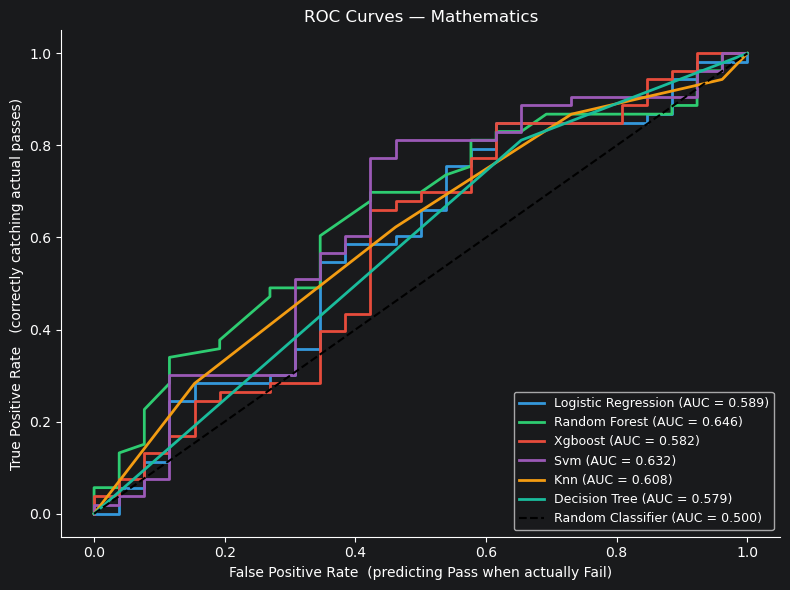

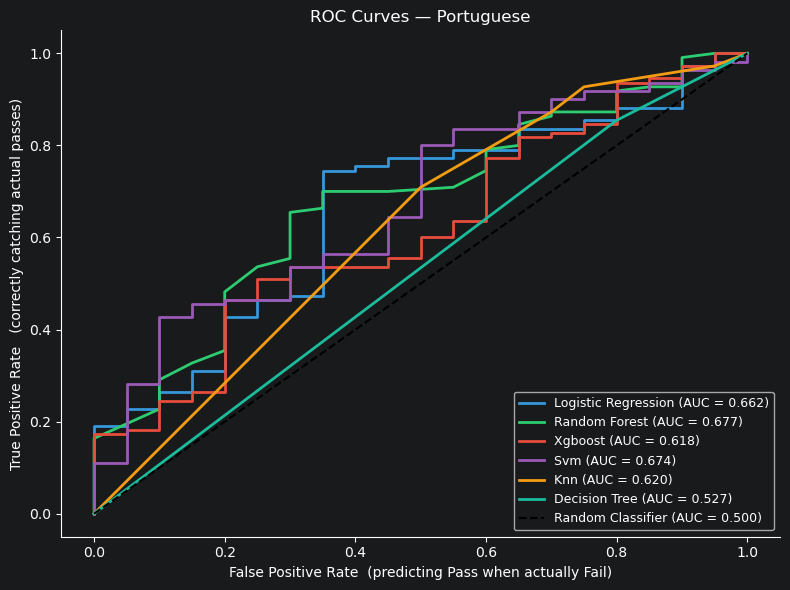

In [50]:
def plot_roc_curves(models_dict, X_test, y_test, title):
    """Plot ROC curves for all models that support predict_proba."""

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c']

    for (name, model), color in zip(models_dict.items(), colors):
        # Only models with predict_proba can produce ROC curves
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_test)[:, 1]  # probability of Pass
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            roc_auc = auc(fpr, tpr)
            display_name = name.replace('_', ' ').title()
            ax.plot(fpr, tpr, color=color, linewidth=2,
                    label=f'{display_name} (AUC = {roc_auc:.3f})')

    # Diagonal = random guessing — your model must beat this line
    ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.500)')

    ax.set_xlabel('False Positive Rate  (predicting Pass when actually Fail)')
    ax.set_ylabel('True Positive Rate   (correctly catching actual passes)')
    ax.set_title(f'ROC Curves — {title}')
    ax.legend(loc='lower right', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()


plot_roc_curves(mat_models, Xt_mat, yt_mat, 'Mathematics')
plot_roc_curves(por_models, Xt_por, yt_por, 'Portuguese')


---

✅ **Notebook complete.** All models saved to `models/`. Launch the Streamlit app with:

```bash
streamlit run app.py
```